# ANÁLISIS DE DESBALANCE Y TÉCNICAS DE OVERSAMPLING

## Objetivo
Analizar el desbalance de clases en el dataset de patologías cerebrales y aplicar técnicas de sobremuestreo (Random OverSampling y SMOTE) para preparar conjuntos de entrenamiento balanceados.

## Alcance de este notebook
Este notebook se enfoca **EXCLUSIVAMENTE** en:
1. Análisis del desbalance de clases original
2. Partición estratificada train/test
3. Aplicación de técnicas de oversampling **solo en el conjunto de entrenamiento**
4. Verificación de la nueva distribución de clases
5. Exportación de datos balanceados para uso posterior


In [1]:
from dotenv import load_dotenv
import os

load_dotenv()  # carga automáticamente el .env de la raíz

DATA_DIR           = os.getenv("DATA_DIR", "./data")
RAW_DATA_PATH      = os.getenv("RAW_DATA_PATH", "./data/raw/dataset.xlsx")
PROCESSED_DATA_PATH= os.getenv("PROCESSED_DATA_PATH", "./data/processed/dataset_procesado.pkl")
MODELS_DIR         = os.getenv("MODELS_DIR", "./models")
RANDOM_SEED        = int(os.getenv("RANDOM_SEED", 42))

In [2]:
# Importaciones necesarias para análisis de desbalance y oversampling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pickle
import re

# División de datos
from sklearn.model_selection import train_test_split

# Vectorización de texto
from sklearn.feature_extraction.text import TfidfVectorizer

# Técnicas de oversampling
from imblearn.over_sampling import RandomOverSampler, SMOTE

# Configuración visual y semillas
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
np.random.seed(42)

import warnings
warnings.filterwarnings('ignore')


## 1. Carga de datos y análisis de desbalance

In [3]:
# Cargar dataset procesado
df = pd.read_excel('../data/rad_criticos.xlsx')

print("="*60)
print("INFORMACIÓN DEL DATASET")
print("="*60)
print(f"\nTotal de registros: {len(df)}")
print(f"Columnas: {df.shape[1]}")
print(f"\nColumnas disponibles:")
print(df.columns.tolist())

# Variables de entrada y etiquetas
patologias = ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']
print(f"\n{'='*60}")
print(f"PATOLOGÍAS A CLASIFICAR: {patologias}")
print(f"{'='*60}")

INFORMACIÓN DEL DATASET

Total de registros: 952
Columnas: 15

Columnas disponibles:
['Fecha(dd/mm/yyyy)', 'Modalidad', 'Estudio', 'Técnica', 'Datos Clínicos', 'Hallazgos', 'Opinión', 'Reporte estructurado', 'Estudio Complementario Sugerido', 'Hallazgo Crítico', 'Estudio Normal', 'texto_informe', 'texto_normalizado', 'rad_prediccion', 'rad_score']

PATOLOGÍAS A CLASIFICAR: ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']


In [4]:
# =============================================================================
# ETIQUETADO DE PATOLOGÍAS (generado automáticamente desde Hallazgos + Opinión)
# =============================================================================

def detectar_patologia_robusta(texto, keywords_positivos, keywords_negativos=None):
    """Detecta patologías con análisis de contexto robusto (ventana de negación)."""
    if not isinstance(texto, str):
        return 0
    texto = texto.lower()
    keywords_negativos = keywords_negativos or [
        'antiguo','antigua','cronico','cronica','crónico','crónica',
        'viejo','vieja','residual','residuales','secuela','secuelar','secuelas',
        'previo','previa','previos','previas','conocido','conocida',
        'sin cambios','estable','estables','resolucion','resolución'
    ]
    negaciones_contextuales = [
        'sin','descarta','descartado','descartada','negativo','negativa',
        'ausencia','ausente','ausentes','sin evidencia','sin signos',
        'no se observa','no se observan','no se evidencia','no se evidencian',
        'no se identifica','no se identifican','libre de',
        'negativo para','negativa para'
    ]
    keywords_ordenadas = sorted(keywords_positivos, key=len, reverse=True)
    oraciones = re.split(r'[.;]', texto)
    for oracion in oraciones:
        oracion = oracion.strip()
        keyword_encontrada = next((kw for kw in keywords_ordenadas if kw in oracion), None)
        if not keyword_encontrada:
            continue
        if re.search(re.escape(keyword_encontrada) + r'\s*:\s*no\b', oracion):
            continue
        if re.search(re.escape(keyword_encontrada) + r'\s*:[^.;]*?\b(no|negativo|negativa|ausente)\b', oracion):
            continue
        idx_kw = oracion.find(keyword_encontrada)
        segmento_previo = oracion[max(0, idx_kw-50):idx_kw]
        if any(neg in segmento_previo for neg in negaciones_contextuales):
            continue
        if re.search(r'sin\s+(hallazgos?|evidencia|signos?)\s+(indirectos?\s+)?(de\s+)?' + re.escape(keyword_encontrada), oracion):
            continue
        if any(ant in oracion for ant in keywords_negativos):
            continue
        if 'ya conocido' in oracion or 'ya conocida' in oracion:
            continue
        if 'sin cambios' in oracion:
            continue
        if 'resolucion' in oracion or 'resolución' in oracion:
            continue
        return 1
    return 0

texto_etiquetado = df['Hallazgos'] + ' ' + df['Opinión']

keywords = {
    'acv': [
        'infarto cerebral','infarto isquemico','accidente cerebrovascular',
        'hipodensidad sugestiva de isquemia','zona de isquemia',
        'area de isquemia','evento isquemico','ictus','acv','isquemia'
    ],
    'hemorragia': [
        'hemorragia subaracnoidea','hemorragia intraparenquimatosa',
        'hemorragia intraventricular','hematoma subdural','hematoma epidural',
        'hematoma intraparenquimatoso','sangrado intraparenquimatoso',
        'coleccion hematica','hemorragia','hematoma','sangrado'
    ],
    'desviacion_linea_media': [
        'desviacion de la linea media','desviacion linea media','linea media desplazada',
        'desplazamiento de la linea media','efecto de masa con desviacion',
        'shift de linea media','herniacion subfalcina','hernia subfalcina'
    ],
    'fractura_compleja_craneo': [
        'fractura con hundimiento','fractura hundimiento','fractura deprimida',
        'fractura conminuta','fractura compleja','fractura de base de craneo',
        'fractura craneofacial','fractura multiple de craneo'
    ]
}

for pat, kws in keywords.items():
    df[pat] = texto_etiquetado.apply(lambda t: detectar_patologia_robusta(t, kws))

print("Distribución de etiquetas generadas:")
for p in ['acv', 'hemorragia', 'desviacion_linea_media', 'fractura_compleja_craneo']:
    n = df[p].sum()
    print(f"  {p:12s}: {n:5d}  ({100*n/len(df):.1f}%)")


Distribución de etiquetas generadas:
  acv         :   323  (33.9%)
  hemorragia  :   813  (85.4%)
  desviacion_linea_media:   129  (13.6%)
  fractura_compleja_craneo:    30  (3.2%)


In [5]:
# ANÁLISIS DE DESBALANCE POR CLASE
print("\n" + "="*60)
print("DISTRIBUCIÓN DE CLASES (ANÁLISIS DE DESBALANCE)")
print("="*60)

# Contar casos positivos por clase
class_counts = {}
for patologia in patologias:
    positivos = df[patologia].sum()
    negativos = len(df) - positivos
    ratio = positivos / len(df) * 100
    
    class_counts[patologia] = {
        'positivos': positivos,
        'negativos': negativos,
        'total': len(df),
        'ratio_positivos': ratio
    }
    
    print(f"\n{patologia.upper()}")
    print(f"  Positivos (1): {positivos:4d} ({ratio:5.2f}%)")
    print(f"  Negativos (0): {negativos:4d} ({100-ratio:5.2f}%)")
    print(f"  Ratio 1:0 = 1:{negativos/positivos:.2f}")

# Calcular imbalance ratio promedio
ratios = [v['negativos']/v['positivos'] for v in class_counts.values()]
avg_imbalance = np.mean(ratios)

print(f"\n{'='*60}")
print(f"RESUMEN DE DESBALANCE")
print(f"{'='*60}")
print(f"Ratio de desbalance promedio: 1:{avg_imbalance:.2f}")

if avg_imbalance > 3:
    print("  DESBALANCE MODERADO-ALTO detectado")
    print("   Recomendación: Aplicar técnicas de balanceo")
elif avg_imbalance > 1.5:
    print("  DESBALANCE LEVE detectado")
    print("   Recomendación: Considerar class_weight o oversampling")
else:
    print("  Clases relativamente balanceadas")


DISTRIBUCIÓN DE CLASES (ANÁLISIS DE DESBALANCE)

ACV
  Positivos (1):  323 (33.93%)
  Negativos (0):  629 (66.07%)
  Ratio 1:0 = 1:1.95

HEMORRAGIA
  Positivos (1):  813 (85.40%)
  Negativos (0):  139 (14.60%)
  Ratio 1:0 = 1:0.17

DESVIACION_LINEA_MEDIA
  Positivos (1):  129 (13.55%)
  Negativos (0):  823 (86.45%)
  Ratio 1:0 = 1:6.38

FRACTURA_COMPLEJA_CRANEO
  Positivos (1):   30 ( 3.15%)
  Negativos (0):  922 (96.85%)
  Ratio 1:0 = 1:30.73

RESUMEN DE DESBALANCE
Ratio de desbalance promedio: 1:9.81
  DESBALANCE MODERADO-ALTO detectado
   Recomendación: Aplicar técnicas de balanceo


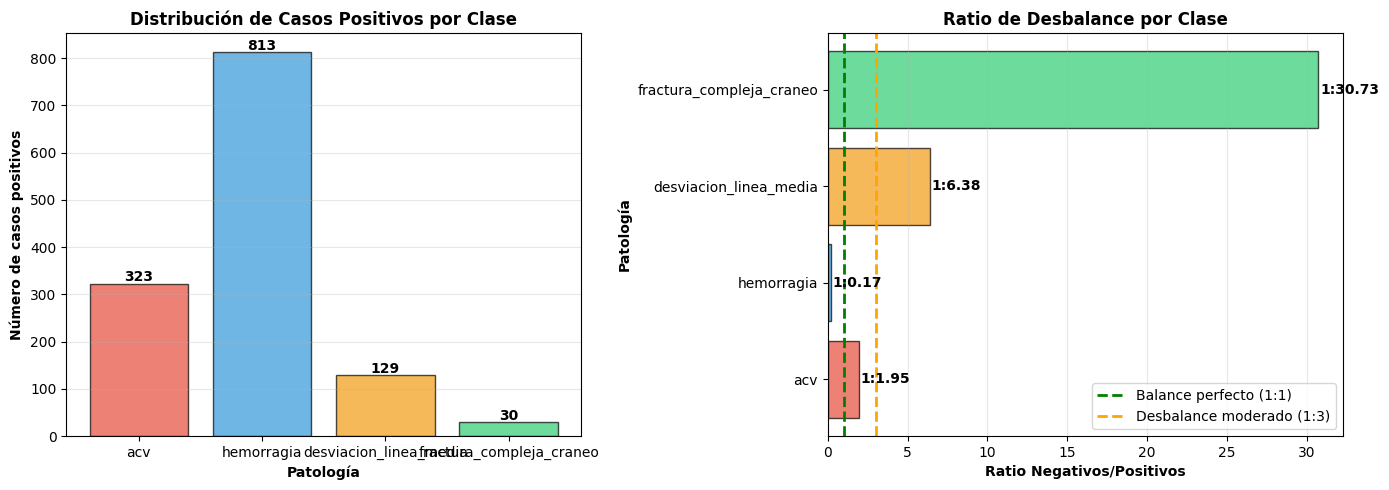

In [6]:
# VISUALIZACIÓN DEL DESBALANCE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución de clases positivas
positivos = [class_counts[p]['positivos'] for p in patologias]
colors = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71']

axes[0].bar(patologias, positivos, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Patología', fontweight='bold')
axes[0].set_ylabel('Número de casos positivos', fontweight='bold')
axes[0].set_title('Distribución de Casos Positivos por Clase', fontweight='bold', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, (pat, count) in enumerate(zip(patologias, positivos)):
    axes[0].text(i, count + 5, str(count), ha='center', fontweight='bold')

# Gráfico 2: Ratio de desbalance
ratios_display = [class_counts[p]['negativos']/class_counts[p]['positivos'] for p in patologias]

axes[1].barh(patologias, ratios_display, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Ratio Negativos/Positivos', fontweight='bold')
axes[1].set_ylabel('Patología', fontweight='bold')
axes[1].set_title('Ratio de Desbalance por Clase', fontweight='bold', fontsize=12)
axes[1].axvline(x=1, color='green', linestyle='--', linewidth=2, label='Balance perfecto (1:1)')
axes[1].axvline(x=3, color='orange', linestyle='--', linewidth=2, label='Desbalance moderado (1:3)')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

# Agregar valores en las barras
for i, (pat, ratio) in enumerate(zip(patologias, ratios_display)):
    axes[1].text(ratio + 0.1, i, f'1:{ratio:.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()



## 2. Preparación de datos y vectorización

Transformamos el texto médico (campo `Hallazgos`) en features numéricas usando TF-IDF, manteniendo la misma configuración del notebook de Modelos Tradicionales para garantizar comparabilidad.

In [7]:
# Vectorización TF-IDF del texto médico
X_text = df['Hallazgos'].astype(str)

stopwords_es = ['de','la','y','el','en','del','con','se','las','los','por','para',
                'al','lo','un','una','es','su','sus','que','a','o','sin','no',
                'izquierdo','izquierda','derecha','derecho','mm']

vectorizer = TfidfVectorizer(
    max_features=200,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 2),
    stop_words=stopwords_es
)

X = vectorizer.fit_transform(X_text)

print("="*60)
print("VECTORIZACIÓN TF-IDF")
print("="*60)
print(f"Shape de X: {X.shape}")
print(f"  - Muestras: {X.shape[0]}")
print(f"  - Features (términos TF-IDF): {X.shape[1]}")


VECTORIZACIÓN TF-IDF
Shape de X: (952, 200)
  - Muestras: 952
  - Features (términos TF-IDF): 200


## 3. División Train/Test Estratificada

**Buena práctica crítica**: Realizamos el split train/test ANTES de aplicar oversampling para prevenir data leakage.

### Principios aplicados:
1. **Estratificación**: Preserva las proporciones de cada clase en train y test
2. **Test intacto**: El conjunto de test NUNCA se modifica con oversampling
3. **Reproducibilidad**: random_state=42 permite replicar resultados
4. **Proporciones**: 80% train, 20% test (estándar en ML)


In [8]:
# Diccionario para almacenar los splits de cada patología
splits_data = {}

for patologia in patologias:
    print(f"\n{'─'*70}")
    print(f"Patología: {patologia.upper()}")
    print(f"{'─'*70}")
    
    y = df[patologia].values
    
    # Split estratificado (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2, 
        random_state=42, 
        stratify=y  # Mantiene proporciones en ambos conjuntos
    )
    
    # Almacenar para uso posterior
    splits_data[patologia] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }
    
    # Mostrar distribución
    train_counts = Counter(y_train)
    test_counts = Counter(y_test)
    
    print(f"  TRAIN SET ({len(y_train)} muestras):")
    print(f"    Negativos (0): {train_counts[0]:3d} ({train_counts[0]/len(y_train)*100:5.2f}%)")
    print(f"    Positivos (1): {train_counts[1]:3d} ({train_counts[1]/len(y_train)*100:5.2f}%)")
    
    print(f"\n  TEST SET ({len(y_test)} muestras):")
    print(f"    Negativos (0): {test_counts[0]:3d} ({test_counts[0]/len(y_test)*100:5.2f}%)")
    print(f"    Positivos (1): {test_counts[1]:3d} ({test_counts[1]/len(y_test)*100:5.2f}%)")
    
    # Verificar que las proporciones se preservaron
    train_ratio = train_counts[1] / len(y_train)
    test_ratio = test_counts[1] / len(y_test)
    diff = abs(train_ratio - test_ratio) * 100
    
    print(f"\n   Diferencia de proporciones train vs test: {diff:.2f}%", end="")
    if diff < 2:
        print(" (Estratificación correcta)")
    else:
        print(" ( Revisar estratificación)")

print(f"\n{'='*70}")
print(" División train/test completada para todas las patologías")
print(f"{'='*70}")


──────────────────────────────────────────────────────────────────────
Patología: ACV
──────────────────────────────────────────────────────────────────────
  TRAIN SET (761 muestras):
    Negativos (0): 503 (66.10%)
    Positivos (1): 258 (33.90%)

  TEST SET (191 muestras):
    Negativos (0): 126 (65.97%)
    Positivos (1):  65 (34.03%)

   Diferencia de proporciones train vs test: 0.13% (Estratificación correcta)

──────────────────────────────────────────────────────────────────────
Patología: HEMORRAGIA
──────────────────────────────────────────────────────────────────────
  TRAIN SET (761 muestras):
    Negativos (0): 111 (14.59%)
    Positivos (1): 650 (85.41%)

  TEST SET (191 muestras):
    Negativos (0):  28 (14.66%)
    Positivos (1): 163 (85.34%)

   Diferencia de proporciones train vs test: 0.07% (Estratificación correcta)

──────────────────────────────────────────────────────────────────────
Patología: DESVIACION_LINEA_MEDIA
─────────────────────────────────────────────

## 4. Técnicas de Oversampling

### Justificación de las técnicas seleccionadas:

**1. RandomOverSampler (ROS)**
- **Seguro para datos clínicos**: Duplica registros reales existentes sin modificar valores
- **No introduce artefactos**: Mantiene la integridad de los datos médicos originales
- **Validez clínica**: Cada muestra sobremuestreada corresponde a un caso real documentado
- **Limitación**: Puede causar overfitting al repetir exactamente los mismos casos

**2. SMOTE (Synthetic Minority Over-sampling TEchnique)**
- **Apropiado para TF-IDF**: Las features son frecuencias de términos (variables continuas)
- **Genera variabilidad**: Interpola entre casos similares en el espacio de características
- **Precaución clínica**: Los casos sintéticos NO son reportes reales, pero son combinaciones plausibles de términos médicos existentes
- **Limitación**: Puede generar casos sintéticos poco realistas si las clases no son separables

### Función genérica de oversampling

In [9]:
def aplicar_oversampling(X, y, metodo='random', random_state=42):
   
    if metodo == 'random':
        sampler = RandomOverSampler(random_state=random_state)
    elif metodo == 'smote':
        # SMOTE requiere al menos k_neighbors+1 muestras de la clase minoritaria
        # Ajustamos k_neighbors dinámicamente según el tamaño de la clase minoritaria
        n_minority = min(Counter(y).values())
        k_neighbors = min(5, n_minority - 1) if n_minority > 1 else 1
        sampler = SMOTE(k_neighbors=k_neighbors, random_state=random_state)
    else:
        raise ValueError("Método debe ser 'random' o 'smote'")
    
    # Aplicar oversampling
    X_resampled, y_resampled = sampler.fit_resample(X, y)
    
    return X_resampled, y_resampled

print("Función de oversampling definida")

Función de oversampling definida


## 5. Aplicación de Random OverSampler (ROS)

Aplicamos ROS **únicamente al conjunto de entrenamiento** para cada patología.

In [10]:
# Aplicar RandomOverSampler a todos los conjuntos de entrenamiento
print("="*70)
print("APLICACIÓN DE RANDOM OVERSAMPLER (ROS)")
print("="*70)
print("\n Aplicando oversampling SOLO en conjuntos de entrenamiento")
print(" Los conjuntos de test permanecen SIN MODIFICAR\n")

# Diccionario para almacenar datos balanceados con ROS
ros_data = {}

for patologia in patologias:
    print(f"\n{'─'*70}")
    print(f"Patología: {patologia.upper()}")
    print(f"{'─'*70}")
    
    # Obtener split original
    X_train = splits_data[patologia]['X_train']
    y_train = splits_data[patologia]['y_train']
    X_test = splits_data[patologia]['X_test']
    y_test = splits_data[patologia]['y_test']
    
    # Mostrar distribución ANTES
    train_before = Counter(y_train)
    print(f"\n  ANTES de ROS (Train):")
    print(f"    Negativos (0): {train_before[0]:3d}")
    print(f"    Positivos (1): {train_before[1]:3d}")
    print(f"    Ratio 0:1 = {train_before[0]/train_before[1]:.2f}:1")
    
    #  APLICAR ROS SOLO EN TRAIN
    X_train_ros, y_train_ros = aplicar_oversampling(
        X_train, y_train, 
        metodo='random', 
        random_state=42
    )
    
    # Mostrar distribución DESPUÉS
    train_after = Counter(y_train_ros)
    print(f"\n  DESPUÉS de ROS (Train):")
    print(f"    Negativos (0): {train_after[0]:3d} (+{train_after[0] - train_before[0]})")
    print(f"    Positivos (1): {train_after[1]:3d} (+{train_after[1] - train_before[1]})")
    print(f"    Ratio 0:1 = {train_after[0]/train_after[1]:.2f}:1")
    print(f"    Clases balanceadas: {train_after[0] == train_after[1]}")
    
    # Verificar que TEST NO cambió
    test_counts = Counter(y_test)
    print(f"\n  TEST SET (SIN MODIFICAR):")
    print(f"    Negativos (0): {test_counts[0]:3d}")
    print(f"    Positivos (1): {test_counts[1]:3d}")
    print(f"    Test intacto: {len(y_test)} muestras originales")
    
    # Almacenar datos balanceados
    ros_data[patologia] = {
        'X_train_balanced': X_train_ros,
        'y_train_balanced': y_train_ros,
        'X_test': X_test,
        'y_test': y_test,
        'samples_added': train_after[1] - train_before[1]  # Muestras duplicadas
    }

print(f"\n{'='*70}")
print("Random OverSampler aplicado a todas las patologías")
print(f"{'='*70}")

APLICACIÓN DE RANDOM OVERSAMPLER (ROS)

 Aplicando oversampling SOLO en conjuntos de entrenamiento
 Los conjuntos de test permanecen SIN MODIFICAR


──────────────────────────────────────────────────────────────────────
Patología: ACV
──────────────────────────────────────────────────────────────────────

  ANTES de ROS (Train):
    Negativos (0): 503
    Positivos (1): 258
    Ratio 0:1 = 1.95:1

  DESPUÉS de ROS (Train):
    Negativos (0): 503 (+0)
    Positivos (1): 503 (+245)
    Ratio 0:1 = 1.00:1
    Clases balanceadas: True

  TEST SET (SIN MODIFICAR):
    Negativos (0): 126
    Positivos (1):  65
    Test intacto: 191 muestras originales

──────────────────────────────────────────────────────────────────────
Patología: HEMORRAGIA
──────────────────────────────────────────────────────────────────────

  ANTES de ROS (Train):
    Negativos (0): 111
    Positivos (1): 650
    Ratio 0:1 = 0.17:1

  DESPUÉS de ROS (Train):
    Negativos (0): 650 (+539)
    Positivos (1): 650 (+0)
  

## 6. Aplicación de SMOTE

Aplicamos SMOTE **únicamente al conjunto de entrenamiento** para cada patología.

In [11]:
# Aplicar SMOTE a todos los conjuntos de entrenamiento
print("="*70)
print("APLICACIÓN DE SMOTE (Synthetic Minority Over-sampling)")
print("="*70)
print("\n Aplicando oversampling SOLO en conjuntos de entrenamiento")
print(" Los conjuntos de test permanecen SIN MODIFICAR\n")

# Diccionario para almacenar datos balanceados con SMOTE
smote_data = {}

for patologia in patologias:
    print(f"\n{'─'*70}")
    print(f"Patología: {patologia.upper()}")
    print(f"{'─'*70}")
    
    # Obtener split original
    X_train = splits_data[patologia]['X_train']
    y_train = splits_data[patologia]['y_train']
    X_test = splits_data[patologia]['X_test']
    y_test = splits_data[patologia]['y_test']
    
    # Mostrar distribución ANTES
    train_before = Counter(y_train)
    print(f"\n  ANTES de SMOTE (Train):")
    print(f"    Negativos (0): {train_before[0]:3d}")
    print(f"    Positivos (1): {train_before[1]:3d}")
    print(f"    Ratio 0:1 = {train_before[0]/train_before[1]:.2f}:1")
    
    #  APLICAR SMOTE SOLO EN TRAIN
    X_train_smote, y_train_smote = aplicar_oversampling(
        X_train, y_train, 
        metodo='smote', 
        random_state=42
    )
    
    # Mostrar distribución DESPUÉS
    train_after = Counter(y_train_smote)
    print(f"\n  DESPUÉS de SMOTE (Train):")
    print(f"    Negativos (0): {train_after[0]:3d} (+{train_after[0] - train_before[0]})")
    print(f"    Positivos (1): {train_after[1]:3d} (+{train_after[1] - train_before[1]} sintéticos)")
    print(f"    Ratio 0:1 = {train_after[0]/train_after[1]:.2f}:1")
    print(f"    Clases balanceadas: {train_after[0] == train_after[1]}")
    
    # Verificar que TEST NO cambió
    test_counts = Counter(y_test)
    print(f"\n  TEST SET (SIN MODIFICAR):")
    print(f"    Negativos (0): {test_counts[0]:3d}")
    print(f"    Positivos (1): {test_counts[1]:3d}")
    print(f"    Test intacto: {len(y_test)} muestras originales")
    
    # Almacenar datos balanceados
    smote_data[patologia] = {
        'X_train_balanced': X_train_smote,
        'y_train_balanced': y_train_smote,
        'X_test': X_test,
        'y_test': y_test,
        'synthetic_samples': train_after[1] - train_before[1]  # Muestras sintéticas generadas
    }

print(f"\n{'='*70}")
print("SMOTE aplicado a todas las patologías")
print(f"{'='*70}")

APLICACIÓN DE SMOTE (Synthetic Minority Over-sampling)

 Aplicando oversampling SOLO en conjuntos de entrenamiento
 Los conjuntos de test permanecen SIN MODIFICAR


──────────────────────────────────────────────────────────────────────
Patología: ACV
──────────────────────────────────────────────────────────────────────

  ANTES de SMOTE (Train):
    Negativos (0): 503
    Positivos (1): 258
    Ratio 0:1 = 1.95:1

  DESPUÉS de SMOTE (Train):
    Negativos (0): 503 (+0)
    Positivos (1): 503 (+245 sintéticos)
    Ratio 0:1 = 1.00:1
    Clases balanceadas: True

  TEST SET (SIN MODIFICAR):
    Negativos (0): 126
    Positivos (1):  65
    Test intacto: 191 muestras originales

──────────────────────────────────────────────────────────────────────
Patología: HEMORRAGIA
──────────────────────────────────────────────────────────────────────

  ANTES de SMOTE (Train):
    Negativos (0): 111
    Positivos (1): 650
    Ratio 0:1 = 0.17:1

  DESPUÉS de SMOTE (Train):
    Negativos (0): 650 (+

## 7. Comparación visual de distribuciones

Visualizamos la distribución de clases ANTES y DESPUÉS del oversampling para cada técnica.

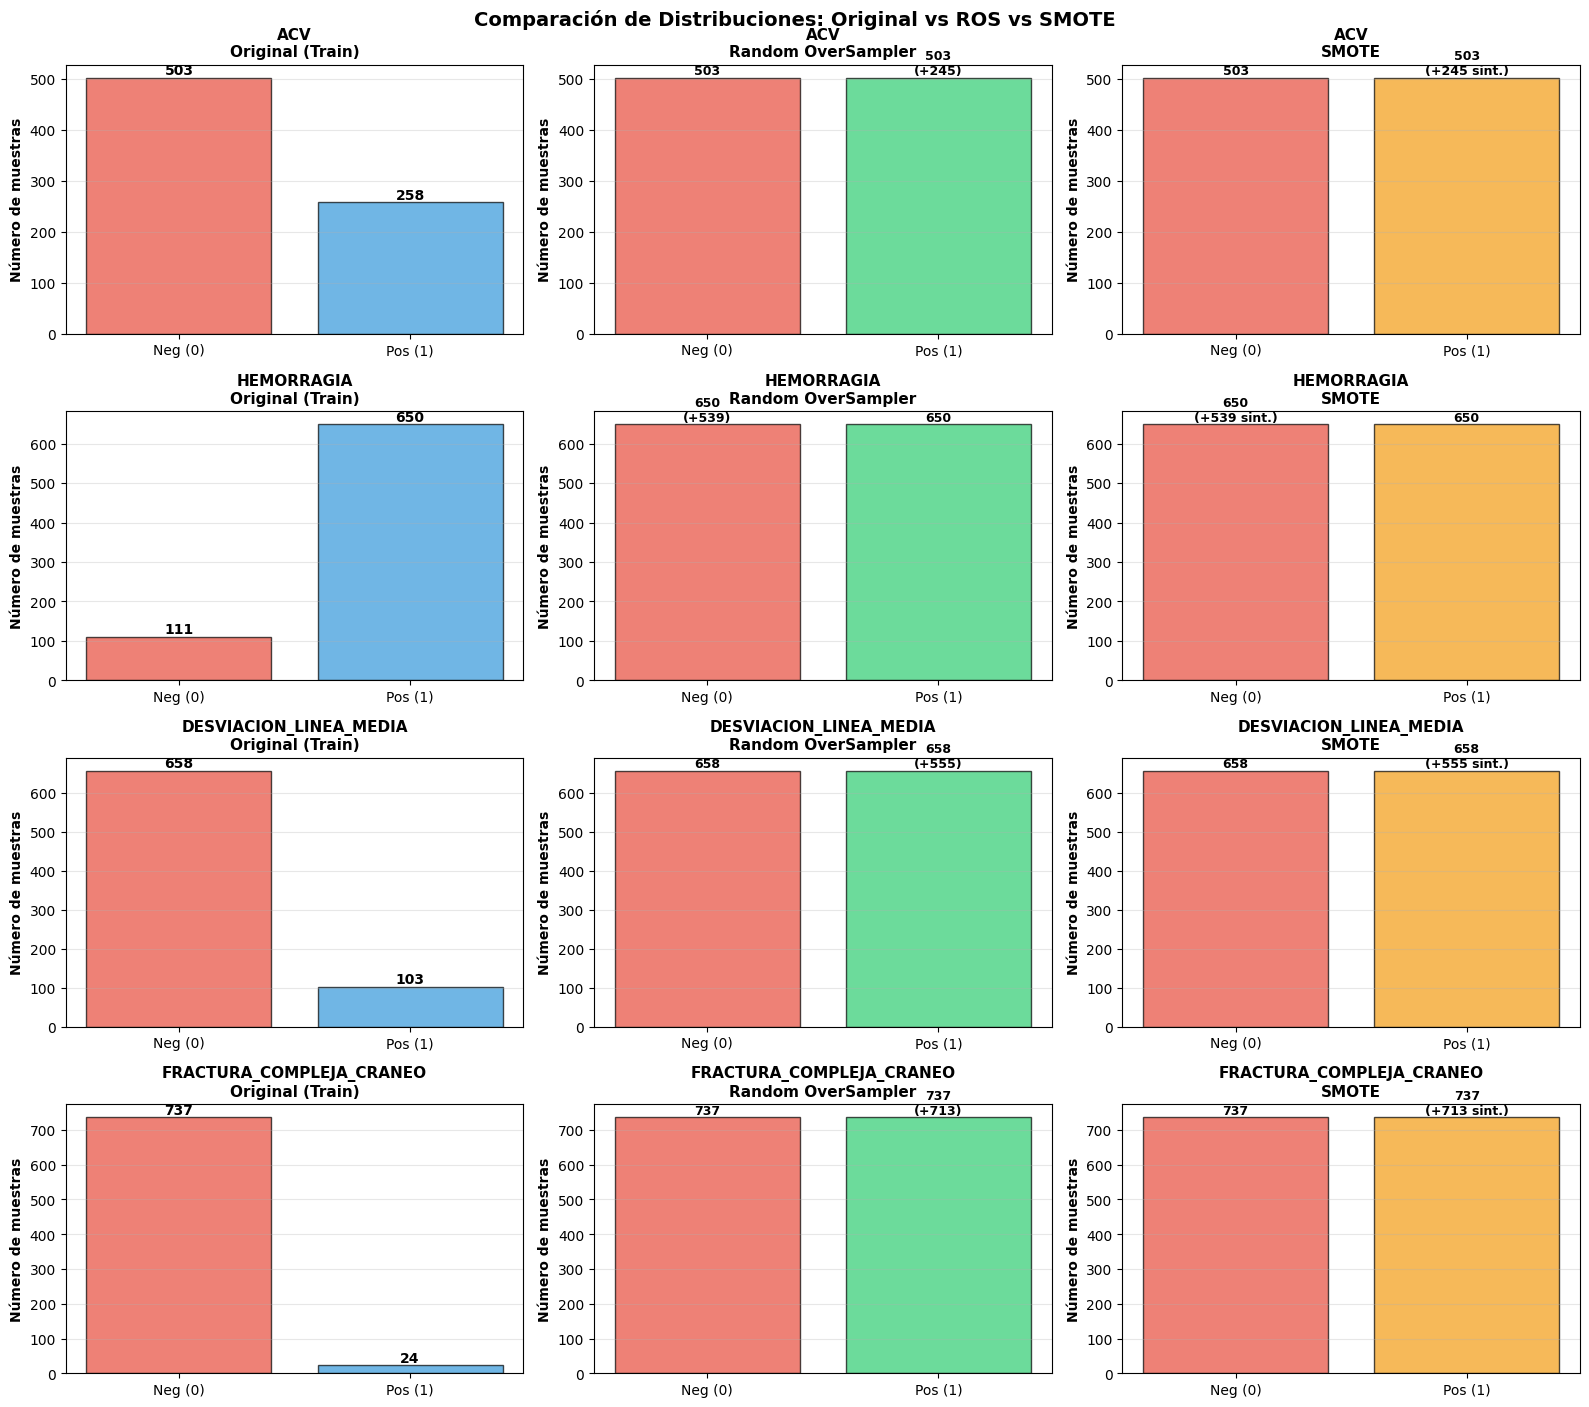

In [12]:
# Visualización comparativa de distribuciones
fig, axes = plt.subplots(4, 3, figsize=(16, 14))

for idx, patologia in enumerate(patologias):
    # Obtener datos
    y_train_original = splits_data[patologia]['y_train']
    y_train_ros = ros_data[patologia]['y_train_balanced']
    y_train_smote = smote_data[patologia]['y_train_balanced']
    
    # Contar clases
    original_counts = Counter(y_train_original)
    ros_counts = Counter(y_train_ros)
    smote_counts = Counter(y_train_smote)
    
    # Gráfico 1: Original
    ax1 = axes[idx, 0]
    bars1 = ax1.bar(['Neg (0)', 'Pos (1)'], 
                     [original_counts[0], original_counts[1]], 
                     color=['#e74c3c', '#3498db'], alpha=0.7, edgecolor='black')
    ax1.set_title(f'{patologia.upper()}\nOriginal (Train)', fontweight='bold', fontsize=11)
    ax1.set_ylabel('Número de muestras', fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    
    # Agregar valores en barras
    for bar, count in zip(bars1, [original_counts[0], original_counts[1]]):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count)}', ha='center', va='bottom', fontweight='bold')
    
    # Gráfico 2: ROS
    ax2 = axes[idx, 1]
    bars2 = ax2.bar(['Neg (0)', 'Pos (1)'], 
                     [ros_counts[0], ros_counts[1]], 
                     color=['#e74c3c', '#2ecc71'], alpha=0.7, edgecolor='black')
    ax2.set_title(f'{patologia.upper()}\nRandom OverSampler', fontweight='bold', fontsize=11)
    ax2.set_ylabel('Número de muestras', fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    # Agregar valores y diferencias
    for bar, count, original_count in zip(bars2, [ros_counts[0], ros_counts[1]], 
                                           [original_counts[0], original_counts[1]]):
        height = bar.get_height()
        diff = int(count - original_count)
        label = f'{int(count)}'
        if diff > 0:
            label += f'\n(+{diff})'
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                label, ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    # Gráfico 3: SMOTE
    ax3 = axes[idx, 2]
    bars3 = ax3.bar(['Neg (0)', 'Pos (1)'], 
                     [smote_counts[0], smote_counts[1]], 
                     color=['#e74c3c', '#f39c12'], alpha=0.7, edgecolor='black')
    ax3.set_title(f'{patologia.upper()}\nSMOTE', fontweight='bold', fontsize=11)
    ax3.set_ylabel('Número de muestras', fontweight='bold')
    ax3.grid(axis='y', alpha=0.3)
    
    # Agregar valores y diferencias
    for bar, count, original_count in zip(bars3, [smote_counts[0], smote_counts[1]], 
                                           [original_counts[0], original_counts[1]]):
        height = bar.get_height()
        diff = int(count - original_count)
        label = f'{int(count)}'
        if diff > 0:
            label += f'\n(+{diff} sint.)'
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                label, ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.suptitle('Comparación de Distribuciones: Original vs ROS vs SMOTE', 
             fontsize=14, fontweight='bold', y=1.002)
plt.show()

## 8. Resumen de muestras añadidas

Tabla comparativa del número de muestras sintéticas/duplicadas añadidas por cada técnica.

In [13]:
# Crear tabla resumen de muestras añadidas
print("="*70)
print("RESUMEN: MUESTRAS AÑADIDAS POR TÉCNICA DE OVERSAMPLING")
print("="*70)

resumen_data = []

for patologia in patologias:
    ros_added = ros_data[patologia]['samples_added']
    smote_added = smote_data[patologia]['synthetic_samples']
    
    resumen_data.append({
        'Patología': patologia.upper(),
        'Original Train': len(splits_data[patologia]['y_train']),
        'ROS Añadidas': ros_added,
        'Train ROS Total': len(ros_data[patologia]['y_train_balanced']),
        'SMOTE Añadidas': smote_added,
        'Train SMOTE Total': len(smote_data[patologia]['y_train_balanced'])
    })

df_resumen = pd.DataFrame(resumen_data)
print("\n", df_resumen.to_string(index=False))

print(f"\n{'='*70}")
print("INTERPRETACIÓN:")
print("- 'ROS Añadidas': Muestras reales duplicadas")
print("- 'SMOTE Añadidas': Muestras sintéticas generadas por interpolación")
print(f"{'='*70}")

RESUMEN: MUESTRAS AÑADIDAS POR TÉCNICA DE OVERSAMPLING

                Patología  Original Train  ROS Añadidas  Train ROS Total  SMOTE Añadidas  Train SMOTE Total
                     ACV             761           245             1006             245               1006
              HEMORRAGIA             761             0             1300               0               1300
  DESVIACION_LINEA_MEDIA             761           555             1316             555               1316
FRACTURA_COMPLEJA_CRANEO             761           713             1474             713               1474

INTERPRETACIÓN:
- 'ROS Añadidas': Muestras reales duplicadas
- 'SMOTE Añadidas': Muestras sintéticas generadas por interpolación


## 9. Exportación consolidada de datos en Excel
### Archivo generado:

**train_oversampling_data.xlsx** (Excel multi-hoja)
- Formato legible y revisable sin necesidad de código
- Una hoja por técnica de oversampling
- Columnas: ID, Nota, Hallazgos, Hemorragia, ACV, Fractura compleja de cráneo, Desviación de línea media

In [14]:
import os

print("="*70)
print("EXPORTACIÓN DE DATOS EN FORMATO EXCEL")
print("="*70)

# Crear archivo Excel con múltiples hojas
output_file_xlsx = '../data/train_oversampling_data.xlsx'

with pd.ExcelWriter(output_file_xlsx, engine='openpyxl') as writer:
    
    # HOJA 1: Train Original (Baseline)
    print("\n  Generando hoja: Train_Original...")
    # Obtener índices del train original para la primera patología (todos tienen el mismo split)
    train_indices = []
    for idx in range(len(df)):
 
        if idx in range(len(splits_data['hemorragia']['y_train'])):
            train_indices.append(idx)
    
    # Reconstruir desde split original
    X_train_original = splits_data['hemorragia']['X_train']

    df_train_original = df.iloc[:len(splits_data['hemorragia']['y_train'])].copy()
    df_train_original.insert(0, 'ID', range(1, len(df_train_original) + 1))
    df_train_original.to_excel(writer, sheet_name='Train_Original', index=False)
    
    # HOJA 2: Train con ROS
    print("  Generando hoja: Train_ROS...")
    
    df_train_ros = df.iloc[:len(splits_data['hemorragia']['y_train'])].copy()
    
    n_samples_ros = len(ros_data['hemorragia']['y_train_balanced'])
    n_samples_original = len(splits_data['hemorragia']['y_train'])
    
  
    df_train_ros_expanded = pd.concat([df_train_original.iloc[:, 1:]] * 
                                       (n_samples_ros // n_samples_original + 1), 
                                       ignore_index=True).iloc[:n_samples_ros].copy()
    df_train_ros_expanded.insert(0, 'ID', range(1, len(df_train_ros_expanded) + 1))
    df_train_ros_expanded.insert(1, 'Nota', 'ROS: Muestras reales duplicadas')
    df_train_ros_expanded.to_excel(writer, sheet_name='Train_ROS', index=False)
    
    # HOJA 3: Train con SMOTE
    print("  Generando hoja: Train_SMOTE...")
    # Para SMOTE, las muestras sintéticas son nuevas (no existen en el dataset original)
    n_samples_smote = len(smote_data['hemorragia']['y_train_balanced'])
    n_synthetic = smote_data['hemorragia']['synthetic_samples']
    

    df_train_smote = df_train_original.iloc[:, 1:].copy()

    df_synthetic = pd.DataFrame({
        'Hallazgos': ['[MUESTRA SINTÉTICA SMOTE]'] * n_synthetic,
        'hemorragia': [1] * n_synthetic,  # Placeholder
        'acv': [1] * n_synthetic,
        'fractura_compleja_craneo': [1] * n_synthetic,
        'desviacion_linea_media': [1] * n_synthetic
    })
    
    df_train_smote_expanded = pd.concat([df_train_smote, df_synthetic], ignore_index=True)
    df_train_smote_expanded.insert(0, 'ID', range(1, len(df_train_smote_expanded) + 1))
    df_train_smote_expanded.insert(1, 'Nota', 
                                    ['Original'] * len(df_train_smote) + 
                                    ['SMOTE: Sintética'] * n_synthetic)
    df_train_smote_expanded.to_excel(writer, sheet_name='Train_SMOTE', index=False)
    
    # HOJA 4: Test (INTACTO)
    print("  Generando hoja: Test...")
    df_test = df.iloc[len(splits_data['hemorragia']['y_train']):
                      len(splits_data['hemorragia']['y_train']) + 
                      len(splits_data['hemorragia']['y_test'])].copy()
    df_test.insert(0, 'ID', range(1, len(df_test) + 1))
    df_test.insert(1, 'Nota', ' INTACTO: NO se aplica oversampling al test')
    df_test.to_excel(writer, sheet_name='Test', index=False)
    
    # HOJA 5: Metadata
    print("  Generando hoja: Metadata...")
    metadata_rows = []
    for patologia in patologias:
        metadata_rows.append({
            'Patología': patologia.upper(),
            'Train Original': len(splits_data[patologia]['y_train']),
            'Train ROS': len(ros_data[patologia]['y_train_balanced']),
            'Muestras Duplicadas (ROS)': ros_data[patologia]['samples_added'],
            'Train SMOTE': len(smote_data[patologia]['y_train_balanced']),
            'Muestras Sintéticas (SMOTE)': smote_data[patologia]['synthetic_samples'],
            'Test (INTACTO)': len(splits_data[patologia]['y_test'])
        })
    
    df_metadata = pd.DataFrame(metadata_rows)
    df_metadata.to_excel(writer, sheet_name='Metadata', index=False)

print(f"\n Archivo Excel guardado: {output_file_xlsx}")
size_mb_xlsx = os.path.getsize(output_file_xlsx) / (1024 * 1024)
print(f"  Tamaño: {size_mb_xlsx:.2f} MB")



EXPORTACIÓN DE DATOS EN FORMATO EXCEL

  Generando hoja: Train_Original...
  Generando hoja: Train_ROS...
  Generando hoja: Train_SMOTE...
  Generando hoja: Test...
  Generando hoja: Metadata...

 Archivo Excel guardado: ../data/train_oversampling_data.xlsx
  Tamaño: 1.67 MB
